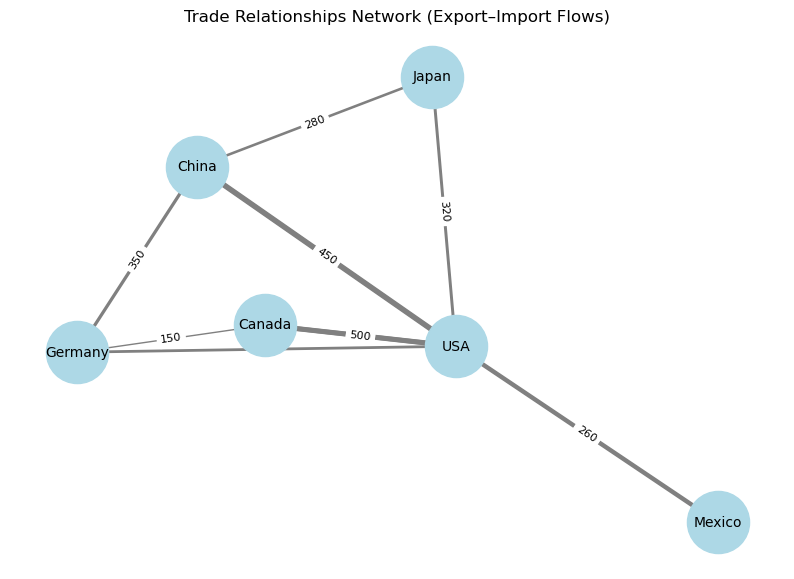

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# -----------------------------
# Trade relationships (exports → imports)
# weight = trade volume (arbitrary units)
# -----------------------------
trade_edges = [
    ("USA", "China", 600),
    ("China", "USA", 450),
    ("USA", "Canada", 550),
    ("Canada", "USA", 500),
    ("USA", "Mexico", 480),
    ("Germany", "USA", 300),
    ("Germany", "China", 350),
    ("Japan", "USA", 320),
    ("China", "Japan", 280),
    ("Mexico", "USA", 260),
    ("Canada", "Germany", 150)
]

# Create directed graph
G = nx.DiGraph()

for u, v, w in trade_edges:
    G.add_edge(u, v, weight=w)

# -----------------------------
# Layout
# -----------------------------
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42)

# -----------------------------
# Node drawing
# -----------------------------
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color="lightblue")

# -----------------------------
# Edge width scaled by trade volume
# -----------------------------
weights = [G[u][v]["weight"] for u, v in G.edges()]
scaled_widths = [w / 150 for w in weights]

nx.draw_networkx_edges(
    G,
    pos,
    width=scaled_widths,
    arrowsize=18,
    edge_color="gray",
    arrowstyle="->"
)

# Labels
nx.draw_networkx_labels(G, pos, font_size=10)

# Edge labels (trade volume)
edge_labels = {(u, v): w for u, v, w in trade_edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Trade Relationships Network (Export–Import Flows)")
plt.axis("off")
plt.show()